# Data Cleaning & Preprocessing Techniques

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Scikit-Learn Preprocessing & Imputation modules
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Plotting settings
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_palette('tab10')
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


## 2. Load Dataset & Data Health Audit

In [2]:
# Load the dataset
df_raw = pd.read_csv('housing_preproc_dataset.csv')
print(f"Dataset Dimensions: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns\n")

# Display first 5 rows
df_raw.head()

Dataset Dimensions: 1000 rows, 8 columns



,Income,House_Age,Rooms,Bedrooms,Square_Feet,Property_Type,City_Tier,Price
0,36117.06,31.0,7.0,2.2,2425.1,Single Family,Tier 1,602000.01
1,150455.46,51.0,3.0,1.0,967.4,Single Family,Tier 3,543582.12
2,74253.56,5.0,4.0,1.9,1389.8,Single Family,Tier 2,522813.55
3,280412.07,19.0,7.0,2.7,2068.6,Single Family,Tier 2,1071545.75
4,22633.12,34.0,8.0,2.6,2347.0,Single Family,Tier 1,566310.55


In [3]:
# Check data types and non-null counts
print("=== Dataset Information ===")
df_raw.info()

# Summary statistics for numerical variables
print("\n=== Summary Statistics (Notice disparities in scales and max values) ===")
df_raw.describe().round(2)

=== Dataset Information ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Income         960 non-null    float64
 1   House_Age      1000 non-null   float64
 2   Rooms          1000 non-null   float64
 3   Bedrooms       935 non-null    float64
 4   Square_Feet    1000 non-null   float64
 5   Property_Type  965 non-null    object 
 6   City_Tier      1000 non-null   object 
 7   Price          1000 non-null   float64
dtypes: float64(6), object(2)
memory usage: 62.6+ KB

=== Summary Statistics (Notice disparities in scales and max values) ===


,Income,House_Age,Rooms,Bedrooms,Square_Feet,Price
count,960.00,1000.00,1000.00,935.00,1000.00,1000.00
mean,64567.25,27.63,5.21,2.33,1926.91,536054.05
std,69753.34,15.34,2.84,1.36,1319.87,259073.09
min,15208.93,1.00,0.00,0.00,0.00,78775.20
25%,27303.34,15.00,3.00,1.50,1151.22,382422.87
50%,46695.80,27.00,5.00,2.10,1740.50,493066.74
75%,78929.38,41.00,6.00,2.90,2294.30,619201.95
max,1029908.32,54.00,22.00,11.70,12703.80,2836893.98


=== Missing Value Health Audit ===
               Missing Count  Missing Percentage (%) Data Type
Bedrooms                  65                     6.5   float64
Income                    40                     4.0   float64
Property_Type             35                     3.5    object


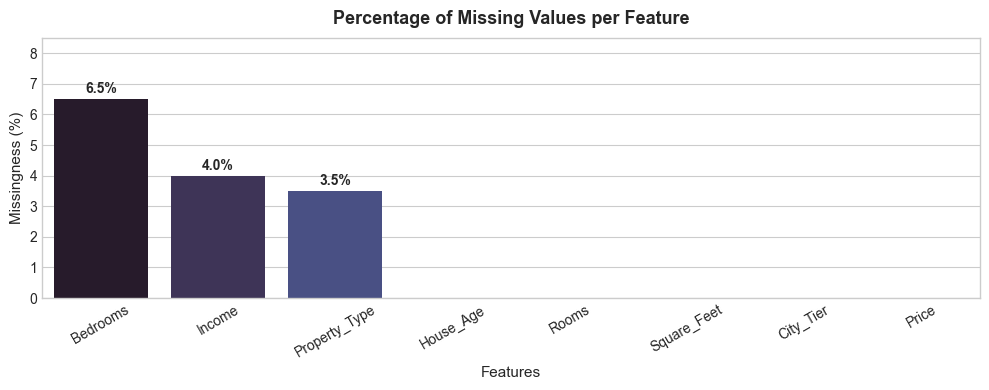

In [4]:
# Missing Value Analysis Table
missing_counts = df_raw.isnull().sum()
missing_percent = (missing_counts / len(df_raw)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing Percentage (%)': missing_percent.round(2),
    'Data Type': df_raw.dtypes
}).sort_values(by='Missing Count', ascending=False)

print("=== Missing Value Health Audit ===")
print(missing_df[missing_df['Missing Count'] > 0])

# Visualize missingness
plt.figure(figsize=(10, 4))
sns.barplot(x=missing_df.index, y=missing_df['Missing Percentage (%)'], palette='mako')
plt.title('Percentage of Missing Values per Feature', fontsize=13, fontweight='bold', pad=10)
plt.ylabel('Missingness (%)', fontsize=11)
plt.xlabel('Features', fontsize=11)
plt.xticks(rotation=30)
plt.ylim(0, max(missing_df['Missing Percentage (%)']) + 2)
for p in plt.gca().patches:
    h = p.get_height()
    if h > 0:
        plt.gca().annotate(f"{h:.1f}%", (p.get_x() + p.get_width() / 2, h + 0.2),
                           ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Handling Missing Values (Median & KNN Imputation)

In [5]:
df_imputed = df_raw.copy()

# 1. Median Imputation for skewed continuous feature 'Income'
median_imputer = SimpleImputer(strategy='median')
df_imputed['Income'] = median_imputer.fit_transform(df_imputed[['Income']])

# 2. Mode (most frequent) Imputation for categorical 'Property_Type'
mode_imputer = SimpleImputer(strategy='most_frequent')
df_imputed['Property_Type'] = mode_imputer.fit_transform(df_imputed[['Property_Type']]).ravel()

print("Univariate Imputation completed:")
print(f"  Income missing after median imputation:        {df_imputed['Income'].isnull().sum()}")
print(f"  Property_Type missing after mode imputation:  {df_imputed['Property_Type'].isnull().sum()}")

Univariate Imputation completed:
  Income missing after median imputation:        0
  Property_Type missing after mode imputation:  0


In [6]:
# 3. Multivariate KNN Imputation for 'Bedrooms' (correlated with Rooms & Square_Feet)
knn_features = ['Rooms', 'Square_Feet', 'Bedrooms']
knn_imputer = KNNImputer(n_neighbors=5)
df_imputed[knn_features] = knn_imputer.fit_transform(df_imputed[knn_features])

print("Multivariate KNN Imputation completed for 'Bedrooms'.")
print("Total remaining missing values in dataset:", df_imputed.isnull().sum().sum())

Multivariate KNN Imputation completed for 'Bedrooms'.
Total remaining missing values in dataset: 0


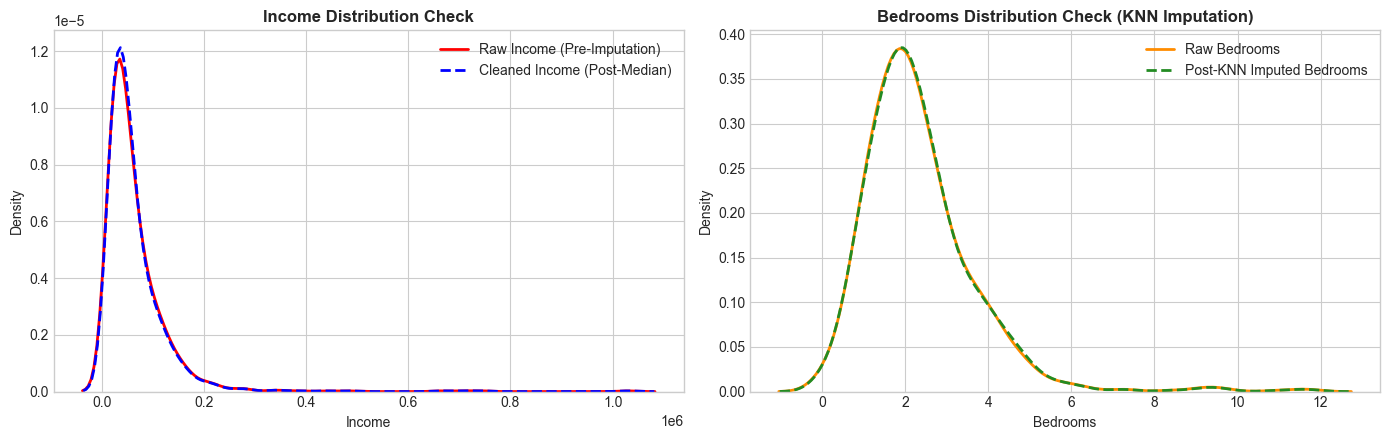

In [7]:
# Compare distributions before and after imputation
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.kdeplot(df_raw['Income'].dropna(), label='Raw Income (Pre-Imputation)', color='red', lw=2, ax=axes[0])
sns.kdeplot(df_imputed['Income'], label='Cleaned Income (Post-Median)', color='blue', linestyle='--', lw=2, ax=axes[0])
axes[0].set_title('Income Distribution Check', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Income')
axes[0].legend()

sns.kdeplot(df_raw['Bedrooms'].dropna(), label='Raw Bedrooms', color='darkorange', lw=2, ax=axes[1])
sns.kdeplot(df_imputed['Bedrooms'], label='Post-KNN Imputed Bedrooms', color='forestgreen', linestyle='--', lw=2, ax=axes[1])
axes[1].set_title('Bedrooms Distribution Check (KNN Imputation)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Bedrooms')
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Outlier Detection (IQR & Z-Score) and Capping

In [8]:
outlier_cols = ['Income', 'Rooms', 'Square_Feet']

def detect_outliers_summary(df, cols):
    records = []
    for col in cols:
        series = df[col]
        # IQR
        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        lower_iqr = q1 - 1.5 * iqr
        upper_iqr = q3 + 1.5 * iqr
        iqr_outliers = ((series < lower_iqr) | (series > upper_iqr)).sum()
        
        # Z-Score
        z = np.abs(stats.zscore(series))
        z_outliers = (z > 3).sum()
        
        records.append({
            'Feature': col,
            'Min': round(series.min(), 1),
            'Q1': round(q1, 1),
            'Median': round(series.median(), 1),
            'Q3': round(q3, 1),
            'Max': round(series.max(), 1),
            'IQR Outliers': iqr_outliers,
            'Z-Score Outliers (|Z|>3)': z_outliers
        })
    return pd.DataFrame(records)

print("=== Outlier Detection Audit ===")
detect_outliers_summary(df_imputed, outlier_cols)

=== Outlier Detection Audit ===


,Feature,Min,Q1,Median,Q3,Max,IQR Outliers,Z-Score Outliers (|Z|>3)
0,Income,15208.9,27723.7,46695.8,76936.5,1029908.3,52,13
1,Rooms,0.0,3.0,5.0,6.0,22.0,28,16
2,Square_Feet,0.0,1151.2,1740.5,2294.3,12703.8,42,23


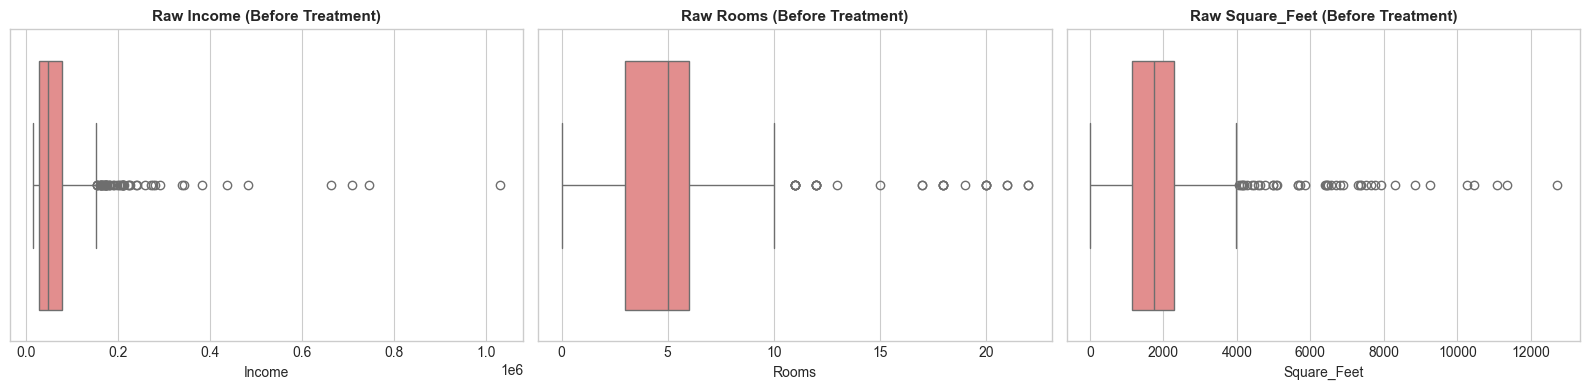

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for idx, col in enumerate(outlier_cols):
    sns.boxplot(x=df_imputed[col], color='lightcoral', ax=axes[idx])
    axes[idx].set_title(f'Raw {col} (Before Treatment)', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel(col)
plt.tight_layout()
plt.show()

In [10]:
df_capped = df_imputed.copy()

# Cap outliers using IQR thresholds
for col in outlier_cols:
    q1 = df_capped[col].quantile(0.25)
    q3 = df_capped[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    # Winsorize / clip values to [lower_bound, upper_bound]
    df_capped[col] = df_capped[col].clip(lower=lower_bound, upper=upper_bound)

print("Winsorization / Capping completed on:", outlier_cols)

Winsorization / Capping completed on: ['Income', 'Rooms', 'Square_Feet']


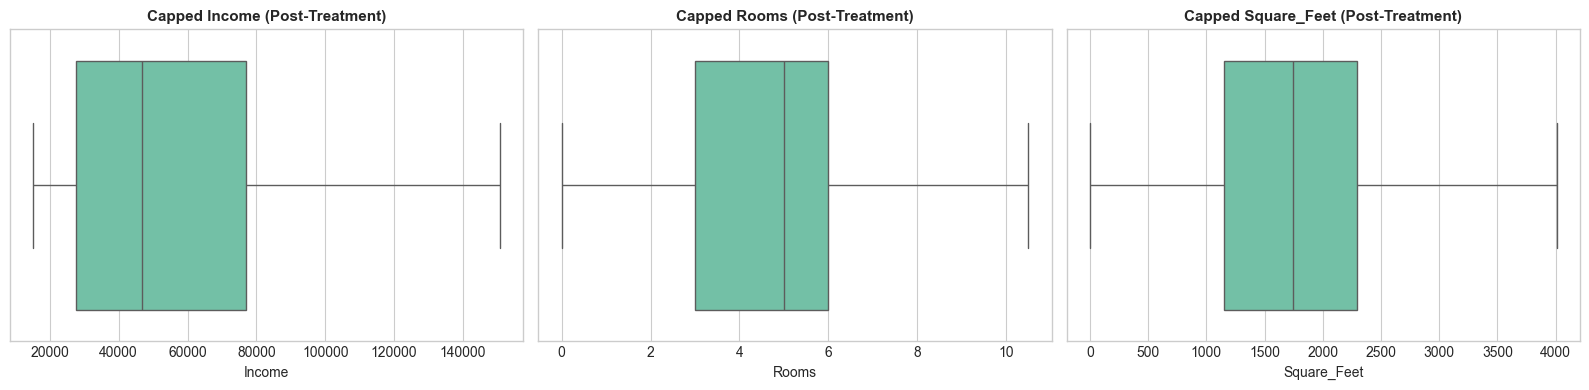

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for idx, col in enumerate(outlier_cols):
    sns.boxplot(x=df_capped[col], color='mediumaquamarine', ax=axes[idx])
    axes[idx].set_title(f'Capped {col} (Post-Treatment)', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel(col)
plt.tight_layout()
plt.show()

## 5. Feature Scaling (StandardScaler, MinMaxScaler, RobustScaler)

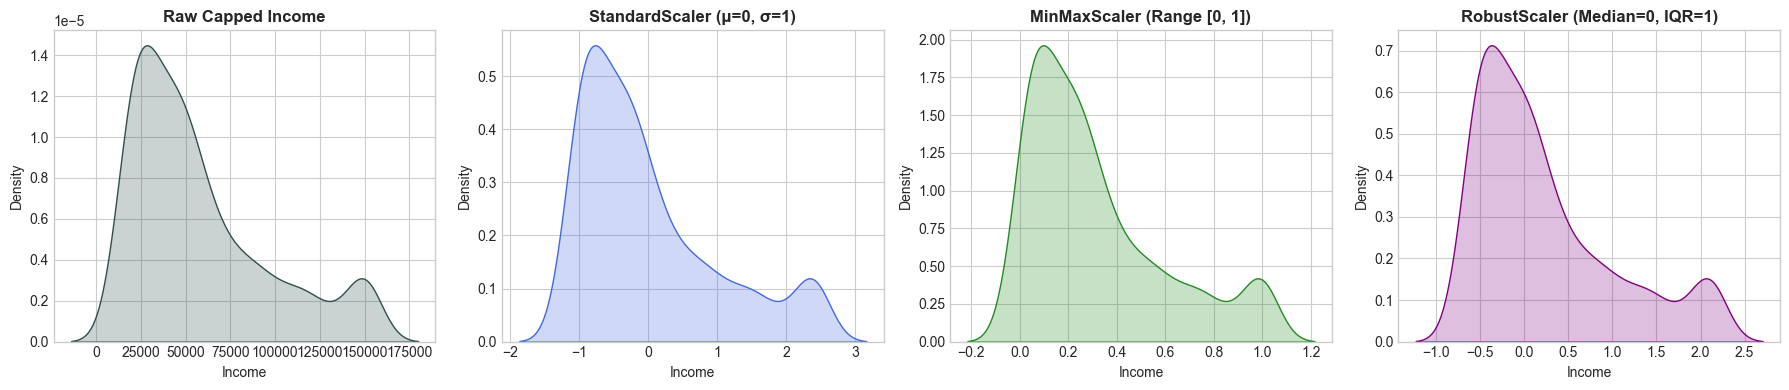

In [12]:
num_cols = ['Income', 'House_Age', 'Rooms', 'Bedrooms', 'Square_Feet']
sample_col = 'Income'

# Apply scalers
standard_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()
robust_scaler = RobustScaler()

df_std = pd.DataFrame(standard_scaler.fit_transform(df_capped[num_cols]), columns=num_cols)
df_minmax = pd.DataFrame(minmax_scaler.fit_transform(df_capped[num_cols]), columns=num_cols)
df_robust = pd.DataFrame(robust_scaler.fit_transform(df_capped[num_cols]), columns=num_cols)

# Plot comparative distributions for sample column
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

sns.kdeplot(df_capped[sample_col], color='darkslategray', fill=True, ax=axes[0])
axes[0].set_title(f'Raw Capped {sample_col}', fontweight='bold')

sns.kdeplot(df_std[sample_col], color='royalblue', fill=True, ax=axes[1])
axes[1].set_title('StandardScaler (μ=0, σ=1)', fontweight='bold')

sns.kdeplot(df_minmax[sample_col], color='forestgreen', fill=True, ax=axes[2])
axes[2].set_title('MinMaxScaler (Range [0, 1])', fontweight='bold')

sns.kdeplot(df_robust[sample_col], color='purple', fill=True, ax=axes[3])
axes[3].set_title('RobustScaler (Median=0, IQR=1)', fontweight='bold')

plt.tight_layout()
plt.show()

## 6. Categorical Feature Encoding (One-Hot & Ordinal)

In [13]:
# Ordinal Encoding with explicit hierarchy
tier_order = [['Tier 3', 'Tier 2', 'Tier 1']]
ordinal_enc = OrdinalEncoder(categories=tier_order)
encoded_tier = ordinal_enc.fit_transform(df_capped[['City_Tier']])

# One-Hot Encoding for nominal Property_Type
ohe = OneHotEncoder(drop='first', sparse_output=False)
encoded_prop = ohe.fit_transform(df_capped[['Property_Type']])
prop_feature_names = ohe.get_feature_names_out(['Property_Type'])

print("Encoded Ordinal 'City_Tier' values (0=Tier 3, 1=Tier 2, 2=Tier 1):")
print(pd.Series(encoded_tier.ravel()).value_counts().to_dict())

print("\nOne-Hot Encoded 'Property_Type' dummy columns:")
print(list(prop_feature_names))

Encoded Ordinal 'City_Tier' values (0=Tier 3, 1=Tier 2, 2=Tier 1):
{1.0: 395, 2.0: 352, 0.0: 253}

One-Hot Encoded 'Property_Type' dummy columns:
['Property_Type_Condo', 'Property_Type_Single Family', 'Property_Type_Townhouse']


## 7. Preprocessing Pipeline (ColumnTransformer)

In [14]:
# Define feature subsets
numeric_features = ['Income', 'House_Age', 'Rooms', 'Bedrooms', 'Square_Feet']
nominal_features = ['Property_Type']
ordinal_features = ['City_Tier']

# 1. Numerical Pipeline: Median Imputation -> Robust Scaling
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

# 2. Nominal Categorical Pipeline: Mode Imputation -> OneHotEncoder
nominal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

# 3. Ordinal Categorical Pipeline: OrdinalEncoder
ordinal_transformer = Pipeline(steps=[
    ('ordinal', OrdinalEncoder(categories=[['Tier 3', 'Tier 2', 'Tier 1']]))
])

# Combine into ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('nom', nominal_transformer, nominal_features),
        ('ord', ordinal_transformer, ordinal_features)
    ]
)

print("Pre-processing ColumnTransformer Pipeline successfully constructed:")
preprocessor

Pre-processing ColumnTransformer Pipeline successfully constructed:


,transformers,"[('num', ...), ('nom', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


## 8. Model Evaluation: Before vs. After Preprocessing

In [15]:
# Prepare features and target
X = df_raw.drop(columns=['Price'])
y = df_raw['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# --- MODEL A: Naive Baseline ---
# Fill NaNs with 0, arbitrary dummy encoding, NO scaling, NO outlier treatment
X_train_naive = pd.get_dummies(X_train.fillna(0), drop_first=True)
X_test_naive = pd.get_dummies(X_test.fillna(0), drop_first=True)
# Align test columns with train
X_test_naive = X_test_naive.reindex(columns=X_train_naive.columns, fill_value=0)

model_naive = Ridge(alpha=100.0)
model_naive.fit(X_train_naive, y_train)
y_pred_naive = model_naive.predict(X_test_naive)

# --- MODEL B: Full Pipeline Preprocessing ---
pipeline_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge(alpha=1.0))
])

pipeline_model.fit(X_train, y_train)
y_pred_clean = pipeline_model.predict(X_test)

# Evaluation Metrics
def get_metrics(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {'Pipeline': name, 'MAE ($)': round(mae, 2), 'RMSE ($)': round(rmse, 2), 'R² Score': round(r2, 4)}

comparison_df = pd.DataFrame([
    get_metrics('Naive Model (Raw / Uncleaned)', y_test, y_pred_naive),
    get_metrics('Engineered Pipeline (Cleaned & Scaled)', y_test, y_pred_clean)
])

print("=== Empirical Validation of Preprocessing on Model Performance ===")
comparison_df

=== Empirical Validation of Preprocessing on Model Performance ===


,Pipeline,MAE ($),RMSE ($),R² Score
0,Naive Model (Raw / Uncleaned),27749.95,87617.00,0.8326
1,Engineered Pipeline (Cleaned & Scaled),23905.66,79569.32,0.8619


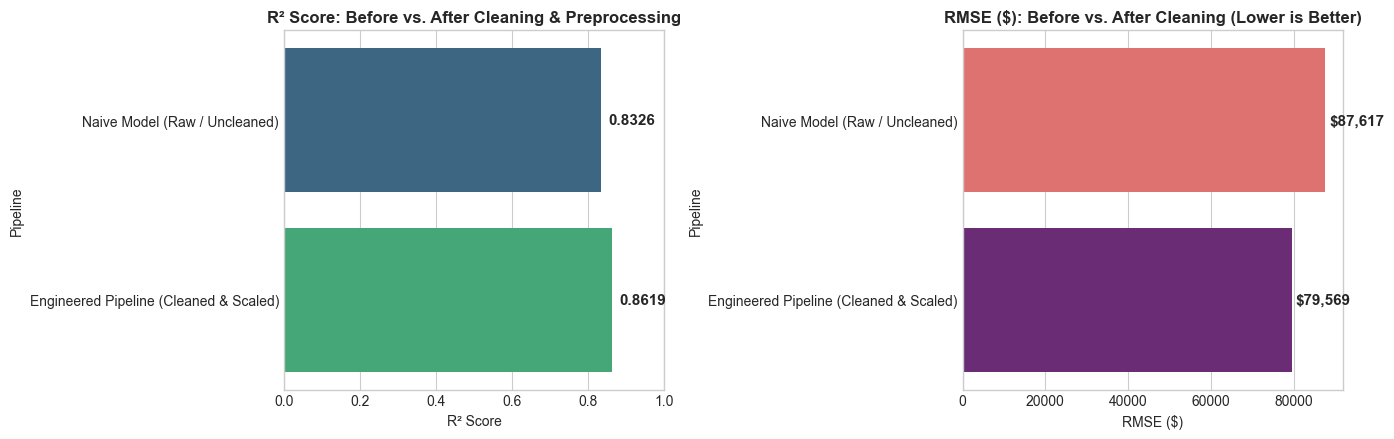

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# R2 Score comparison
sns.barplot(data=comparison_df, x='R² Score', y='Pipeline', palette='viridis', ax=axes[0])
axes[0].set_title('R² Score: Before vs. After Cleaning & Preprocessing', fontsize=12, fontweight='bold')
axes[0].set_xlim(0, 1.0)
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_width():.4f}", 
                     (p.get_width() + 0.02, p.get_y() + p.get_height() / 2),
                     va='center', fontsize=11, fontweight='bold')

# RMSE comparison
sns.barplot(data=comparison_df, x='RMSE ($)', y='Pipeline', palette='magma_r', ax=axes[1])
axes[1].set_title('RMSE ($): Before vs. After Cleaning (Lower is Better)', fontsize=12, fontweight='bold')
for p in axes[1].patches:
    axes[1].annotate(f"${p.get_width():,.0f}", 
                     (p.get_width() + 1000, p.get_y() + p.get_height() / 2),
                     va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## 9. Conclusion